# Final Project

#### Imports

In [77]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision.io import read_image, ImageReadMode
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import pandas as pd
import string
import time
import os
from datetime import datetime

# Use GPU if available, fall back to CPU otherwise
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.backends.cudnn.benchmark = True

NUM_WORKERS = min(4, os.cpu_count() or 1)
PIN_MEMORY = device.type == "cuda"

Using device: cuda


### Task A - Initial Setup
#### Loading Dataset
b) Download the EMNIST dataset. Note that it contains 6 variants, so called splits, which differ in size and contents. For the first half of the project, you should be using the ‘letters’ split. After loading the dataset, plot a random selection of image samples and the corresponding labels (similar to Figure 1.).

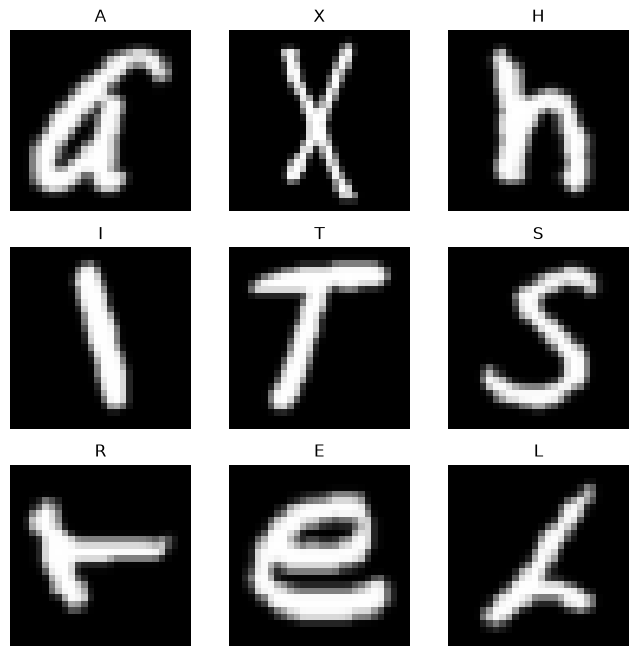

In [78]:
training_data = datasets.EMNIST(
    root="data",
    split="letters",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.EMNIST(
    root="data",
    split="letters",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

letters = ["N/A"] + list(string.ascii_uppercase)

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(letters[label])
    plt.axis("off")
    plt.imshow(img.squeeze().T, cmap="gray")
plt.show()

### Offload work to GPU

In [79]:
class GPUTensorLoader:
    """Drop-in DataLoader replacement that keeps the entire dataset resident on
    the GPU, so batching happens with zero CPU-side work per step."""
    def __init__(self, images, labels, batch_size, shuffle=True):
        self.images = images
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle

    def __iter__(self):
        n = self.images.size(0)
        indices = torch.randperm(n, device=self.images.device) if self.shuffle \
            else torch.arange(n, device=self.images.device)
        for start in range(0, n, self.batch_size):
            batch_idx = indices[start:start + self.batch_size]
            yield self.images[batch_idx], self.labels[batch_idx]

    def __len__(self):
        return (self.images.size(0) + self.batch_size - 1) // self.batch_size


def dataset_to_gpu_tensors(dataset, device):
    loader = DataLoader(dataset, batch_size=len(dataset), num_workers=0)
    images, labels = next(iter(loader))
    return images.to(device), labels.to(device)

def try_load_to_device(dataset, device):
    """Attempt to load the entire dataset onto `device` as tensors.
    Returns (images, labels) on success, or None if it doesn't fit
    (e.g. a laptop with a small/entry-level GPU, or very limited RAM)."""
    try:
        return dataset_to_gpu_tensors(dataset, device)
    except (RuntimeError, MemoryError) as e:
        if device.type == "cuda":
            torch.cuda.empty_cache()
        print(f"Not enough {device.type.upper()} memory to hold the full dataset "
              f"({e}). Falling back to a standard DataLoader for this dataset.")
        return None


def build_loader(dataset, batch_size, shuffle, cached_tensors):
    """Uses the GPU/CPU-resident tensors if available, otherwise a normal
    multi-worker DataLoader."""
    if cached_tensors is not None:
        images, labels = cached_tensors
        return GPUTensorLoader(images, labels, batch_size=batch_size, shuffle=shuffle)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
    )

#### Basic learning functionality
c) Implement a program that defines the simple CNN model depicted in see Figure 2. and trains letter classification on the loaded dataset from step b). Implement two functions that use the given model and respective dataset for training and testing. Using cross entropy loss can be a convenient loss function, since it does not require normalized input. In addition, your program should visualize (plot) the training loss and record the total training time.

##### Create Data Loader

In [80]:
batch_size = 512

train_tensors = try_load_to_device(training_data, device)
test_tensors = try_load_to_device(test_data, device)

training_loader = build_loader(training_data, batch_size, True, train_tensors)
test_loader = build_loader(test_data, batch_size, False, test_tensors)


##### Define CNN

In [81]:
class Model:
    def __init__(self, model, learning_rate, batch_size, description="simple-cnn", device=device, label_offset=1):
        self.device = device
        self.model = model.to(self.device)
        self.criterion = torch.nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate)
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.layers = sum(1 for _ in self.model.modules()) - 1
        self.description = description
        self.label_offset = label_offset

    # TRAINING FUNCTION
    def train(self, loader):
        self.model.train()

        running_loss = 0
        batch_losses = []

        for images, labels in loader:
            images = images.to(self.device)
            labels = labels.to(self.device) - self.label_offset

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.criterion(outputs, labels)

            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            batch_losses.append(loss.item())

        average_loss = running_loss / len(loader)

        return average_loss, batch_losses

    # TESTING FUNCTION
    def test(self, loader):
        self.model.eval()

        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in loader:
                images = images.to(self.device)
                labels = labels.to(self.device) - self.label_offset

                outputs = self.model(images)
                predictions = outputs.argmax(dim=1)

                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        accuracy = 100 * correct / total
        return accuracy

    # SAVE MODEL HELPER FUNCTION
    def save_model(self, loss_history=None, epochs=0, accuracy=None, model_dir="models", figs_dir="figs", show_plot=False):
        os.makedirs(model_dir, exist_ok=True)
        os.makedirs(figs_dir, exist_ok=True)

        timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
        acc_part = f"_acc{accuracy:.2f}" if accuracy is not None else ""

        base_name = (
            f"cnn_{self.description}"
            f"_epo{epochs}"
            f"_lr{self.learning_rate}"
            f"_bs{self.batch_size}"
            f"_lay{self.layers}"
            f"_optAdam"
            f"{acc_part}"
            f"_{timestamp}"
        )

        model_path = os.path.join(model_dir, base_name + ".pth")
        torch.save(self.model.state_dict(), model_path)
        print(f"Model saved to: {model_path}")

        if loss_history is not None and epochs != 0:
            fig_path = os.path.join(figs_dir, base_name + "_loss_history.png")
            save_loss_plot(loss_history, filename=fig_path, show_plot=show_plot)
            print(f"Plot saved to: {fig_path}")

        return model_path

##### Training Loop

In [82]:
def training_loop(model, epochs, train_loader, test_loader, verbose=True):
    loss_history = []

    start_time = time.time()

    for epoch in range(epochs):
        avg_loss, batch_losses = model.train(train_loader)
        loss_history.append(batch_losses)

        accuracy = model.test(test_loader)

        if verbose:
            print(
                f"Epoch {epoch+1}/{epochs}  "
                f"Loss {avg_loss:.4f}  "
                f"Accuracy {accuracy:.2f}%"
            )

    training_time = time.time() - start_time

    if verbose:
        print(f"\nTraining time: {training_time:.2f} seconds")

    return loss_history, training_time


##### Training Loss Plot

In [83]:
def save_loss_plot(loss_history, filename, show_plot=False):
    plt.figure(figsize=(8, 5))

    for epoch, losses in enumerate(loss_history):
        plt.plot(losses, label=f"Epoch {epoch+1}")

    plt.xlabel("Batch")
    plt.ylabel("Loss")
    plt.title("Training Loss per Batch")
    plt.legend()
    plt.savefig(filename)

    if show_plot:
        plt.show()
    else:
        plt.close()


#### Define Simple CNN Model

In [84]:
def make_simple_architecture():
    return torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Flatten(),
        torch.nn.Linear(in_features=8 * 14 * 14, out_features=26),
    )

### Task B
#### b) Adding more Layers


In [85]:
def make_architecture_1():
    # Two convolutions before a single pool at the end ("pooling-at-end")
    return torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.Conv2d(in_channels=8, out_channels=8, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Flatten(),
        torch.nn.Linear(in_features=8 * 14 * 14, out_features=26),
    )

In [86]:
def make_architecture_2():
    # Pool after each conv ("pooling-between")
    return torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Flatten(),
        torch.nn.Linear(in_features=16 * 7 * 7, out_features=26),
    )

In [87]:
def make_architecture_3():
    # Adds a hidden fully-connected layer before the output ("more-layers")
    return torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Flatten(),
        torch.nn.Linear(in_features=16 * 7 * 7, out_features=64),
        torch.nn.ReLU(),
        torch.nn.Linear(in_features=64, out_features=26),
    )

#### c) number of feature maps and the Size of the convolution Kernel

In [88]:
def make_architecture_4():
    # More feature maps: 16 -> 32 instead of 8 -> 16 ("more-feature-maps")
    return torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Flatten(),
        torch.nn.Linear(in_features=32 * 7 * 7, out_features=64),
        torch.nn.ReLU(),
        torch.nn.Linear(in_features=64, out_features=26),
    )

In [89]:
def make_architecture_5():
    # Larger convolution kernels: 5x5 instead of 3x3 ("larger-kernels")
    return torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=7, padding=3),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Conv2d(in_channels=8, out_channels=16, kernel_size=7, padding=3),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Flatten(),
        torch.nn.Linear(in_features=16 * 7 * 7, out_features=64),
        torch.nn.ReLU(),
        torch.nn.Linear(in_features=64, out_features=26),
    )


##### Automated Experiments

In [90]:
experiments = [
    # --- Architecture comparison (task b/c) ---
    {"name": "simple-cnn",        "arch_fn": make_simple_architecture, "lr": 0.001,  "batch_size": 512, "epochs": 5},
    {"name": "pooling-at-end",    "arch_fn": make_architecture_1,      "lr": 0.001,  "batch_size": 512, "epochs": 5},
    {"name": "pooling-between",   "arch_fn": make_architecture_2,      "lr": 0.001,  "batch_size": 512, "epochs": 5},
    {"name": "more-layers",       "arch_fn": make_architecture_3,      "lr": 0.001,  "batch_size": 512, "epochs": 5},
    {"name": "more-feature-maps", "arch_fn": make_architecture_4,      "lr": 0.001,  "batch_size": 512, "epochs": 5},
    {"name": "larger-kernels",    "arch_fn": make_architecture_5,      "lr": 0.001,  "batch_size": 512, "epochs": 5},

    # --- Learning-rate sweep using architecture 5 as base (best one currently, afaik) ---
    {"name": "lr-0.01",           "arch_fn": make_architecture_5,      "lr": 0.01,   "batch_size": 512, "epochs": 5},
    {"name": "lr-0.001",          "arch_fn": make_architecture_5,      "lr": 0.001,  "batch_size": 512, "epochs": 5},
    {"name": "lr-0.0001",         "arch_fn": make_architecture_5,      "lr": 0.0001, "batch_size": 512, "epochs": 5},

    # --- Batch-size sweep ---
    {"name": "batch-64",          "arch_fn": make_architecture_5,      "lr": 0.001,  "batch_size": 64,  "epochs": 5},
    {"name": "batch-256",         "arch_fn": make_architecture_5,      "lr": 0.001,  "batch_size": 256, "epochs": 5},

    # --- Epoch sweep ---
    {"name": "epochs-3",          "arch_fn": make_architecture_5,      "lr": 0.001,  "batch_size": 512, "epochs": 3},
    {"name": "epochs-10",         "arch_fn": make_architecture_5,      "lr": 0.001,  "batch_size": 512, "epochs": 10},

    {"name": "b-64-ep-10",        "arch_fn": make_architecture_5,      "lr": 0.001,  "batch_size": 64, "epochs": 10},

]

print(f"{len(experiments)} experiments queued.")


14 experiments queued.


In [91]:
results = []

for cfg in experiments:
    print(f"\n=== Running experiment: {cfg['name']} ===")

    architecture = cfg["arch_fn"]()
    exp_train_loader = build_loader(training_data, cfg["batch_size"], True, train_tensors)
    exp_test_loader = build_loader(test_data, cfg["batch_size"], False, test_tensors)

    model = Model(
        architecture,
        learning_rate=cfg["lr"],
        batch_size=cfg["batch_size"],
        description=cfg["name"],
    )

    loss_history, training_time = training_loop(
        model,
        epochs=cfg["epochs"],
        train_loader=exp_train_loader,
        test_loader=exp_test_loader,
    )
    accuracy = model.test(exp_test_loader)

    results.append({
        "name": cfg["name"],
        "learning_rate": cfg["lr"],
        "batch_size": cfg["batch_size"],
        "epochs": cfg["epochs"],
        "layers": model.layers,
        "accuracy": accuracy,
        "training_time_sec": training_time,
        "model": model,
        "loss_history": loss_history,
    })

results_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ("model", "loss_history")} for r in results]
).sort_values("accuracy", ascending=False).reset_index(drop=True)

results_df



=== Running experiment: simple-cnn ===
Epoch 1/5  Loss 1.2666  Accuracy 76.98%
Epoch 2/5  Loss 0.6332  Accuracy 84.31%
Epoch 3/5  Loss 0.4791  Accuracy 86.52%
Epoch 4/5  Loss 0.4180  Accuracy 87.75%
Epoch 5/5  Loss 0.3865  Accuracy 88.24%

Training time: 3.16 seconds

=== Running experiment: pooling-at-end ===
Epoch 1/5  Loss 1.1479  Accuracy 79.17%
Epoch 2/5  Loss 0.5307  Accuracy 87.18%
Epoch 3/5  Loss 0.4008  Accuracy 87.97%
Epoch 4/5  Loss 0.3572  Accuracy 89.25%
Epoch 5/5  Loss 0.3304  Accuracy 89.25%

Training time: 5.15 seconds

=== Running experiment: pooling-between ===
Epoch 1/5  Loss 1.1528  Accuracy 82.40%
Epoch 2/5  Loss 0.4638  Accuracy 87.61%
Epoch 3/5  Loss 0.3654  Accuracy 89.19%
Epoch 4/5  Loss 0.3222  Accuracy 89.99%
Epoch 5/5  Loss 0.2980  Accuracy 90.66%

Training time: 3.86 seconds

=== Running experiment: more-layers ===
Epoch 1/5  Loss 1.2652  Accuracy 78.58%
Epoch 2/5  Loss 0.5608  Accuracy 85.65%
Epoch 3/5  Loss 0.4129  Accuracy 87.68%
Epoch 4/5  Loss 0.3547 

,name,learning_rate,batch_size,epochs,layers,accuracy,training_time_sec
0,b-64-ep-10,0.0010,64,10,10,92.865385,58.441185
1,lr-0.01,0.0100,512,5,10,92.394231,4.248343
2,epochs-10,0.0010,512,10,10,92.197115,8.760818
3,batch-64,0.0010,64,5,10,92.000000,28.435318
4,more-feature-maps,0.0010,512,5,10,91.927885,5.387001
5,batch-256,0.0010,256,5,10,91.798077,7.041246
6,lr-0.001,0.0010,512,5,10,91.346154,4.164369
7,larger-kernels,0.0010,512,5,10,91.129808,4.287988
8,pooling-between,0.0010,512,5,8,90.658654,3.863652
9,epochs-3,0.0010,512,3,10,89.961538,2.609150


##### Visual Comparison

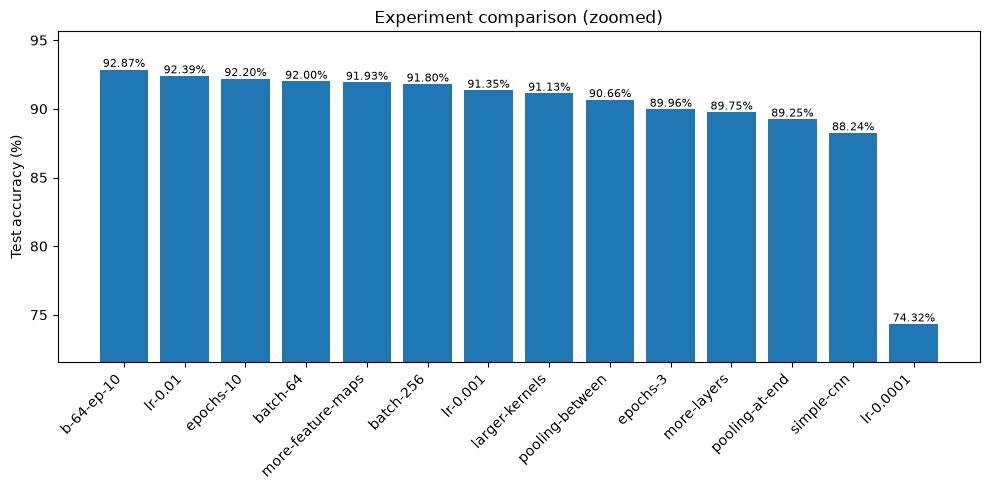

In [105]:
plt.figure(figsize=(10, 5))
bars = plt.bar(results_df["name"], results_df["accuracy"])

# Zoom the y-axis to the actual spread of the data instead of starting at 0
acc_min, acc_max = results_df["accuracy"].min(), results_df["accuracy"].max()
padding = max((acc_max - acc_min) * 0.15, 0.5)  # at least a little padding even if values are near-identical
plt.ylim(acc_min - padding, acc_max + padding)

# Label each bar with its exact value, since small differences are hard to read off the axis alone
for bar, acc in zip(bars, results_df["accuracy"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{acc:.2f}%",
              ha="center", va="bottom", fontsize=8)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Test accuracy (%)")
plt.title("Experiment comparison (zoomed)")
plt.tight_layout()
plt.show()

##### Simple CNN visualisation

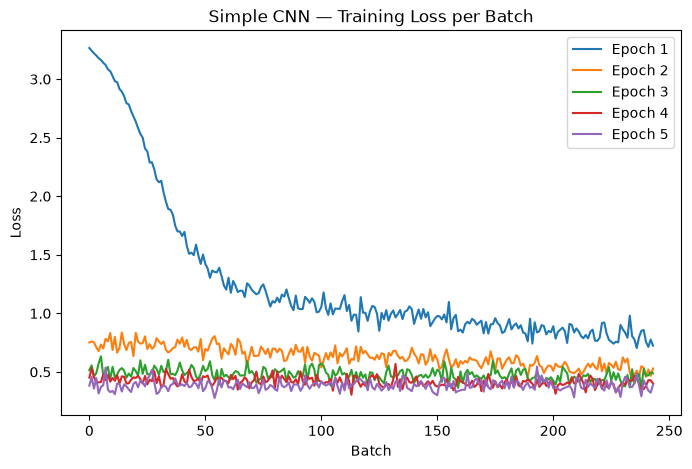

In [93]:
simple_cnn_result = next(r for r in results if r["name"] == "simple-cnn")

plt.figure(figsize=(8, 5))
for epoch, batch_losses in enumerate(simple_cnn_result["loss_history"]):
    plt.plot(batch_losses, label=f"Epoch {epoch + 1}")

plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Simple CNN — Training Loss per Batch")
plt.legend()
plt.show()

##### First Model Visualisation

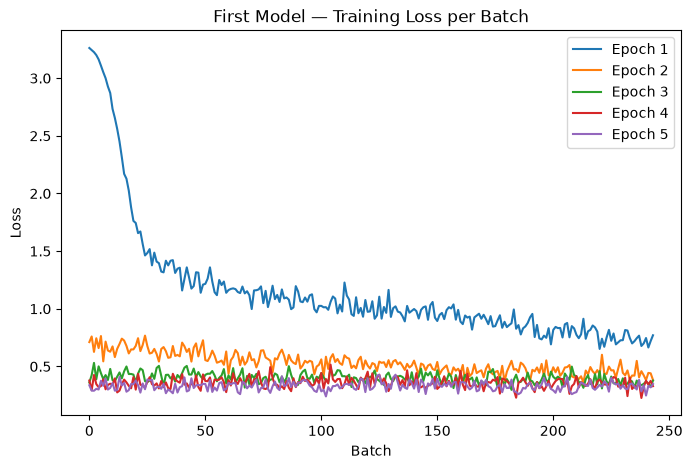

In [94]:
simple_cnn_result = next(r for r in results if r["name"] == "pooling-at-end")

plt.figure(figsize=(8, 5))
for epoch, batch_losses in enumerate(simple_cnn_result["loss_history"]):
    plt.plot(batch_losses, label=f"Epoch {epoch + 1}")

plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("First Model — Training Loss per Batch")
plt.legend()
plt.show()

##### Second Model Visualisation

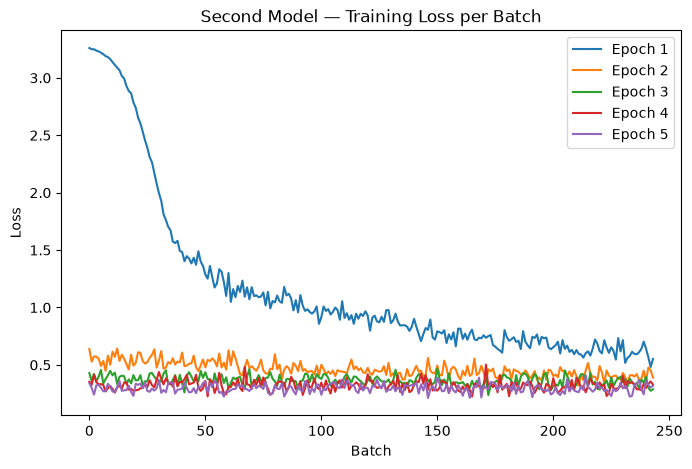

In [95]:
simple_cnn_result = next(r for r in results if r["name"] == "pooling-between")

plt.figure(figsize=(8, 5))
for epoch, batch_losses in enumerate(simple_cnn_result["loss_history"]):
    plt.plot(batch_losses, label=f"Epoch {epoch + 1}")

plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Second Model — Training Loss per Batch")
plt.legend()
plt.show()

##### Third Model Visualisation

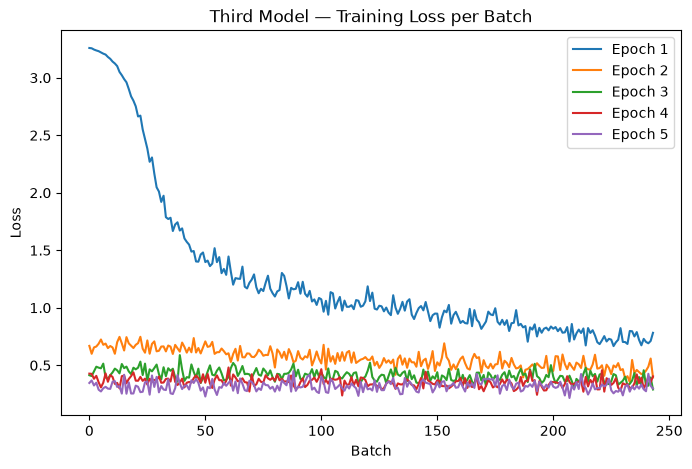

In [96]:
simple_cnn_result = next(r for r in results if r["name"] == "more-layers")

plt.figure(figsize=(8, 5))
for epoch, batch_losses in enumerate(simple_cnn_result["loss_history"]):
    plt.plot(batch_losses, label=f"Epoch {epoch + 1}")

plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Third Model — Training Loss per Batch")
plt.legend()
plt.show()

##### e) Save the best performer

Best experiment: b-64-ep-10
  Accuracy:      92.87%
  Learning rate: 0.001
  Batch size:    64
  Epochs:        10
  Training time: 58.44s
Model saved to: models\cnn_b-64-ep-10_epo10_lr0.001_bs64_lay10_optAdam_acc92.87_20260814-125353.pth


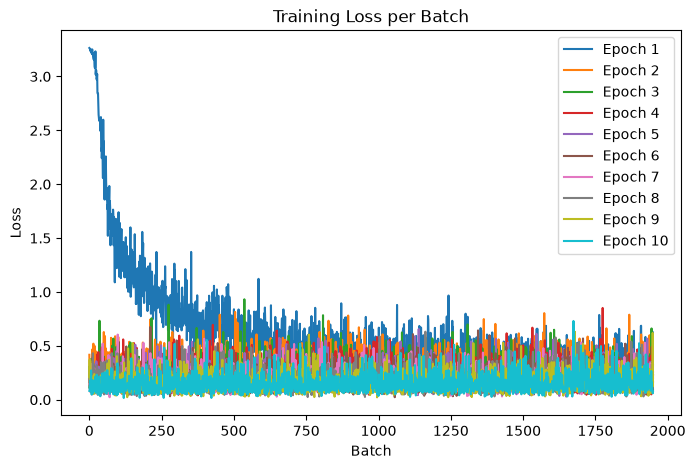

Plot saved to: figs\cnn_b-64-ep-10_epo10_lr0.001_bs64_lay10_optAdam_acc92.87_20260814-125353_loss_history.png


In [97]:
best = max(results, key=lambda r: r["accuracy"])

print(f"Best experiment: {best['name']}")
print(f"  Accuracy:      {best['accuracy']:.2f}%")
print(f"  Learning rate: {best['learning_rate']}")
print(f"  Batch size:    {best['batch_size']}")
print(f"  Epochs:        {best['epochs']}")
print(f"  Training time: {best['training_time_sec']:.2f}s")

best_model_path = best["model"].save_model(
    loss_history=best["loss_history"],
    epochs=best["epochs"],
    accuracy=best["accuracy"],
    show_plot=True,
)


### Task C - Transfer Learning
Transfer learning is a technique that allows faster training by utilizing existing models pre-trained on large datasets. To simulate this behavior, your task is to train a model to for digit classification (only 10 classes) on the basis of an existing letter classifier. You can find an example for transfer learning in [4].
#### a) MNIST Dataset
Download the **MNIST** training and test datasets or, alternately, use the **‘digits’ split of the EMNIST** dataset, which contain grayscale images of the digits 0-9.

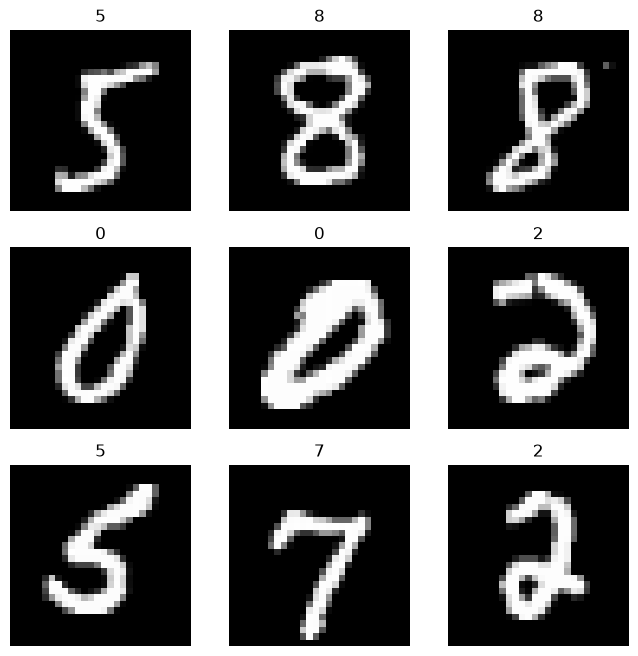

In [98]:
train_images_mnist_dev, train_labels_mnist_dev = dataset_to_gpu_tensors(training_data_MNIST, device)
test_images_mnist_dev, test_labels_mnist_dev = dataset_to_gpu_tensors(test_data_MNIST, device)

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data_MNIST), size=(1,)).item()
    img, label = training_data_MNIST[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

#### b) Load Best Performing Model
Load your **best performing letter classification model** from task B e). Make sure that you are loading the complete state dictionary of the previously saved model.

In [99]:
best_architecture = next(
    config["arch_fn"]()
    for config in experiments
    if config["name"] == best["name"]
)

# Load the complete state dictionary
state_dict = torch.load(
    best_model_path,
    map_location=device,
    weights_only=True
)

best_architecture.load_state_dict(state_dict)

best_architecture = best_architecture.to(device)

best_architecture.eval()

print("Best letter classification model loaded successfully.")

Best letter classification model loaded successfully.


#### c) Final Fully Connected Layer Match Output Classes
Modify the architecture of your model such that the final fully connected layer matches the expected number of output classes. There should be no further modifications of the loaded pre-trained model.

In [100]:
old_layer = best_architecture[-1]

best_architecture[-1] = torch.nn.Linear(
    in_features=old_layer.in_features,
    out_features=10
)

print(best_architecture)

Sequential(
  (0): Conv2d(1, 8, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(8, 16, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=784, out_features=64, bias=True)
  (8): ReLU()
  (9): Linear(in_features=64, out_features=10, bias=True)
)


#### d) Transfer Learning
Conduct **transfer learning** by freezing all layers except the last one during training. The goal is to train only the weights of the final fully connected layer of your model.

Trainable parameters:
9.weight: 640
9.bias: 10
Total parameters: 57,578
Trainable parameters: 650
Frozen parameters: 56,928
Epoch 1/10  Loss 1.1174  Accuracy 86.27%
Epoch 2/10  Loss 0.4113  Accuracy 90.99%
Epoch 3/10  Loss 0.3142  Accuracy 92.09%
Epoch 4/10  Loss 0.2728  Accuracy 92.82%
Epoch 5/10  Loss 0.2493  Accuracy 93.26%
Epoch 6/10  Loss 0.2357  Accuracy 93.59%
Epoch 7/10  Loss 0.2247  Accuracy 93.66%
Epoch 8/10  Loss 0.2186  Accuracy 93.80%
Epoch 9/10  Loss 0.2125  Accuracy 93.81%
Epoch 10/10  Loss 0.2086  Accuracy 93.96%

Training time: 52.96 seconds
Model saved to: models\cnn_transfer-learning-mnist_epo10_lr0.001_bs64_lay10_optAdam_acc93.96_20260814-125506.pth


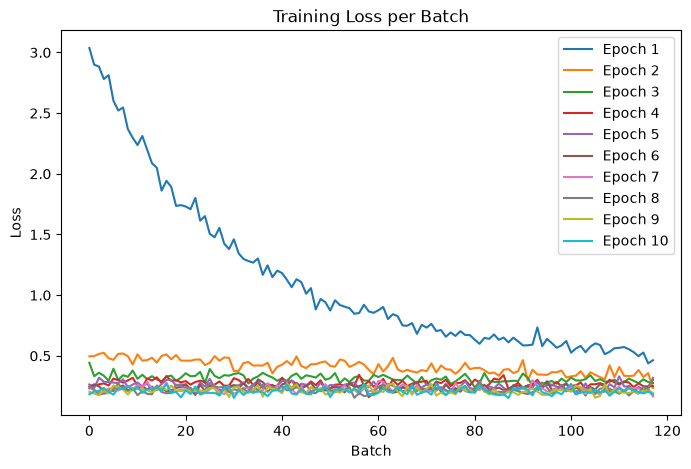

Plot saved to: figs\cnn_transfer-learning-mnist_epo10_lr0.001_bs64_lay10_optAdam_acc93.96_20260814-125506_loss_history.png
MNIST transfer-learning accuracy: 93.96%


In [101]:
for param in best_architecture.parameters():
    param.requires_grad = False

final_layer = best_architecture[-1]

for param in final_layer.parameters():
    param.requires_grad = True

print("Trainable parameters:")
for name, param in best_architecture.named_parameters():
    if param.requires_grad:
        print(f"{name}: {param.numel():,}")

total_parameters = sum(param.numel() for param in best_architecture.parameters())
trainable_parameters = sum(param.numel() for param in best_architecture.parameters() if param.requires_grad)

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Frozen parameters: {total_parameters - trainable_parameters:,}")


mnist_model = Model(
    best_architecture,
    learning_rate=0.001,
    batch_size=64,
    description="transfer-learning-mnist",
    label_offset=0
)

mnist_model.optimizer = torch.optim.Adam(
    filter(lambda param: param.requires_grad, mnist_model.model.parameters()),
    lr=0.001
)


mnist_training_loader = DataLoader(
    training_data_MNIST,
    batch_size=batch_size,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

mnist_test_loader = DataLoader(
    test_data_MNIST,
    batch_size=batch_size,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

loss_history, training_time = training_loop(
    mnist_model,
    epochs=10,
    train_loader=mnist_training_loader,
    test_loader=mnist_test_loader,
)

accuracy = mnist_model.test(mnist_test_loader)

mnist_model_path = mnist_model.save_model(
    loss_history=loss_history,
    epochs=10,
    accuracy=accuracy,
    show_plot=True,
)

print(f"MNIST transfer-learning accuracy: {accuracy:.2f}%")

### Task D - Results Evaluation

a) Implement an inference function that takes as in input a single image (or a path to image file folder) and returns the predicted class label(s). User your two final image classifiers (one for letters, and one for digits) to classify all of our test images.

In [102]:
def emnist_style_preprocess(image, margin=4):
    # image: float tensor, shape (1, H, W), values in [0, 1]
    img = image.squeeze(0)

    # MNIST/EMNIST = white strokes on a black background.
    # If this image looks like a bright background, assume black-on-white and invert it.
    if img.mean().item() > 0.5:
        img = 1.0 - img

    # Crop to the bounding box of the actual ink, discarding background/noise
    mask = img > 0.15
    if mask.any():
        rows = torch.any(mask, dim=1).nonzero(as_tuple=True)[0]
        cols = torch.any(mask, dim=0).nonzero(as_tuple=True)[0]
        top, bottom = rows.min().item(), rows.max().item()
        left, right = cols.min().item(), cols.max().item()
        img = img[top:bottom + 1, left:right + 1]

    # Resize the cropped character into a centered box (mirrors MNIST's ~20x20-in-28x28 convention)
    inner = 28 - 2 * margin
    img = img.unsqueeze(0).unsqueeze(0)
    img = torch.nn.functional.interpolate(img, size=(inner, inner), mode="bilinear", align_corners=False)
    img = img.squeeze(0).squeeze(0)

    canvas = torch.zeros((28, 28), dtype=img.dtype)
    canvas[margin:28 - margin, margin:28 - margin] = img
    return canvas.unsqueeze(0)

In [103]:
class ImageDirectoryDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        # Filter for common image extensions
        valid_exts = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')
        self.img_names = [f for f in os.listdir(img_dir) if f.lower().endswith(valid_exts)]
        self.transform = transform

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)

        image = read_image(img_path, mode=ImageReadMode.GRAY)

        if self.transform:
            image = self.transform(image)

        return image, img_name

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Lambda(emnist_style_preprocess)
])

dataset_letters = ImageDirectoryDataset(img_dir="../letters/", transform=transform)
dataset_digits = ImageDirectoryDataset(img_dir="../digits/", transform=transform)

dataloader_letters = DataLoader(
    dataset_letters,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

dataloader_digits = DataLoader(
    dataset_digits,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

def inference_loop(model, dataloader, digits=False):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    results = []

    with torch.inference_mode():
        for images, filenames in dataloader:
            images = images.to(device, non_blocking=True)

            if not digits: images = images.transpose(2,3)

            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)

            # Immediately extract CPU primitives to avoid keeping tensors in VRAM
            preds_list = predictions.cpu().tolist()
            for name, pred in zip(filenames, preds_list):
                results.append({"filename": name, "prediction": pred if digits else string.ascii_uppercase[pred]})

    return results

results_letters = inference_loop(best["model"].model, dataloader_letters)
print("=== Own Letter Prediction ===")
for result in results_letters:
    true_label = result["filename"][0]
    predicted_label = result["prediction"]
    print(f"True label: {true_label}, Predicted label {predicted_label}\n")
results_digits = inference_loop(mnist_model.model, dataloader_digits, True)
print("=== Own Digit Prediction ===")
for result in results_digits:
    true_label = result["filename"][0]
    predicted_label = result["prediction"]
    print(f"True label: {true_label}, Predicted label {predicted_label}\n")

=== Own Letter Prediction ===
True label: A, Predicted label A

True label: a, Predicted label A

True label: A, Predicted label A

True label: a, Predicted label A

True label: b, Predicted label B

True label: b, Predicted label B

True label: B, Predicted label B

True label: b, Predicted label B

True label: c, Predicted label C

True label: c, Predicted label C

True label: c, Predicted label C

True label: c, Predicted label C

True label: D, Predicted label D

True label: d, Predicted label D

True label: d, Predicted label D

True label: d, Predicted label D

True label: E, Predicted label E

True label: e, Predicted label E

True label: f, Predicted label R

True label: f, Predicted label F

True label: i, Predicted label I

True label: i, Predicted label Z

=== Own Digit Prediction ===
True label: 1, Predicted label 7

True label: 1, Predicted label 7

True label: 2, Predicted label 2

True label: 2, Predicted label 9

True label: 3, Predicted label 3

True label: 3, Predicte

Letters — own images: 90.91% (20/22 correct)
Digits  — own images: 42.86% (6/14 correct)

Letters:


,filename,true_label,predicted_label,correct
0,A-chris.png,A,A,True
1,a-chris2.png,A,A,True
2,A-theresa.jpg,A,A,True
3,a-theresa2.jpg,A,A,True
4,b-chris.png,B,B,True
5,b-chris2.png,B,B,True
6,B-theresa.jpg,B,B,True
7,b-theresa2.jpg,B,B,True
8,c-chris.png,C,C,True
9,c-chris2.png,C,C,True



Digits:


,filename,true_label,predicted_label,correct
0,1-chris.png,1,7,False
1,1-theresa.jpg,1,7,False
2,2-chris.png,2,2,True
3,2-theresa.jpg,2,9,False
4,3-chris.png,3,3,True
5,3-theresa.jpg,3,3,True
6,4-jakob.png,4,7,False
7,5-jakob.png,5,5,True
8,7-chris.png,7,3,False
9,7-new-jakob.png,7,7,True


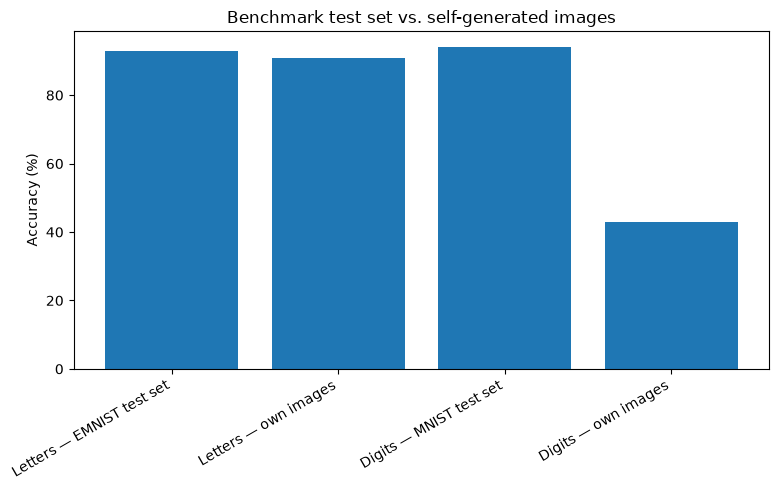

,classifier,accuracy
0,Letters — EMNIST test set,92.865385
1,Letters — own images,90.909091
2,Digits — MNIST test set,93.960000
3,Digits — own images,42.857143


In [104]:
def build_comparison_df(results):
    rows = []
    for r in results:
        true_label = str(r["filename"][0]).upper()
        predicted_label = str(r["prediction"]).upper()
        rows.append({
            "filename": r["filename"],
            "true_label": true_label,
            "predicted_label": predicted_label,
            "correct": true_label == predicted_label,
        })
    return pd.DataFrame(rows)

letters_comparison = build_comparison_df(results_letters)
digits_comparison = build_comparison_df(results_digits)

letters_own_accuracy = letters_comparison["correct"].mean() * 100
digits_own_accuracy = digits_comparison["correct"].mean() * 100

print(f"Letters — own images: {letters_own_accuracy:.2f}% "
      f"({letters_comparison['correct'].sum()}/{len(letters_comparison)} correct)")
print(f"Digits  — own images: {digits_own_accuracy:.2f}% "
      f"({digits_comparison['correct'].sum()}/{len(digits_comparison)} correct)")

print("\nLetters:")
display(letters_comparison)
print("\nDigits:")
display(digits_comparison)

# Benchmark (standard test set) vs. own hand-drawn images, for both classifiers
comparison_summary = pd.DataFrame([
    {"classifier": "Letters — EMNIST test set", "accuracy": best["accuracy"]},
    {"classifier": "Letters — own images",      "accuracy": letters_own_accuracy},
    {"classifier": "Digits — MNIST test set",   "accuracy": accuracy},  # from the transfer-learning cell
    {"classifier": "Digits — own images",       "accuracy": digits_own_accuracy},
])

plt.figure(figsize=(8, 5))
plt.bar(comparison_summary["classifier"], comparison_summary["accuracy"])
plt.ylabel("Accuracy (%)")
plt.title("Benchmark test set vs. self-generated images")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

comparison_summary